# People Analytics — Análise Exploratória de Rotatividade

## 1. Preparação do Ambiente

Este notebook apresenta a análise exploratória da base tratada de colaboradores, com foco na identificação de padrões associados à rotatividade.

Serão analisados indicadores demográficos, profissionais, financeiros e comportamentais para apoiar a geração de insights e recomendações de negócio.

In [75]:
# Importa as bibliotecas utilizadas na análise e visualização dos dados
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configura a visualização completa das colunas e padroniza o estilo dos gráficos
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [76]:
# Define o caminho relativo do arquivo CSV gerado no processo de tratamento
caminho_base_tratada = Path(
    "../data/People_Analytics_Base_Tratada.csv"
)

# Importa a base tratada e converte as colunas de data automaticamente
df = pd.read_csv(
    caminho_base_tratada,
    encoding="utf-8-sig",
    parse_dates=[
        "data_admissao",
        "data_desligamento"
    ]
)

# Exibe as primeiras linhas para validar a importação
df.head()

,colaborador_id,idade,genero,estado_civil,escolaridade,area,cargo,nivel_cargo,data_admissao,tempo_empresa_anos,salario_mensal,distancia_casa_km,horas_extras,viagens_negocio,satisfacao_trabalho,satisfacao_ambiente,equilibrio_vida_trabalho,avaliacao_desempenho,treinamentos_ultimo_ano,recebeu_promocao_5_anos,rotatividade,data_desligamento,motivo_desligamento
0,COL-0001,38,Masculino,Casado(a),Mestrado,Atendimento,Analista de Atendimento,3,2013-12-13,12,7800.0,11,Não,Raramente,1,1,3,3,3,Sim,Sim,2023-07-28 04:45:25.596,Falta de perspectiva de crescimento
1,COL-0002,61,Feminino,Casado(a),Pós-graduação,Recursos Humanos,Especialista de Pessoas,5,2025-03-07,1,12950.0,49,Não,Frequentemente,5,2,2,5,3,Não,Não,NaT,Não se aplica
2,COL-0003,51,Não binário,Casado(a),Graduação,Operações,Coordenador de Operações,4,2022-05-18,4,11400.0,39,Não,Raramente,4,5,4,3,4,Não,Não,NaT,Não se aplica
3,COL-0004,34,Feminino,União estável,Tecnólogo,Tecnologia,Analista de Dados,3,2021-05-28,4,11450.0,46,Não,Raramente,3,2,4,4,3,Não,Não,NaT,Não se aplica
4,COL-0005,46,Feminino,União estável,Pós-graduação,Financeiro,Controller,3,2015-11-10,11,9550.0,35,Não,Nunca,3,3,4,3,1,Sim,Não,NaT,Não se aplica


In [77]:
# Apresenta as dimensões e a estrutura da base utilizada na análise
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

df.info()

Quantidade de registros: 1200
Quantidade de colunas: 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   colaborador_id            1200 non-null   object        
 1   idade                     1200 non-null   int64         
 2   genero                    1200 non-null   object        
 3   estado_civil              1200 non-null   object        
 4   escolaridade              1200 non-null   object        
 5   area                      1200 non-null   object        
 6   cargo                     1200 non-null   object        
 7   nivel_cargo               1200 non-null   int64         
 8   data_admissao             1200 non-null   datetime64[ns]
 9   tempo_empresa_anos        1200 non-null   int64         
 10  salario_mensal            1200 non-null   float64       
 11  distancia_casa_km         

 # 2. Indicadores Gerais de People Analytics

Nesta etapa, serão calculados os principais indicadores da força de trabalho, incluindo quantidade de colaboradores, desligamentos e taxa geral de rotatividade.

A taxa de rotatividade representa a proporção de colaboradores desligados em relação ao total de registros analisados.

In [78]:
# Converte a variável de rotatividade em formato numérico para facilitar os cálculos
df["rotatividade_flag"] = df["rotatividade"].map({
    "Não": 0,
    "Sim": 1
})

# Confirma se todos os registros foram convertidos corretamente
df["rotatividade_flag"].value_counts(dropna=False)

rotatividade_flag
0    877
1    323
Name: count, dtype: int64

In [79]:
# Calcula a quantidade total de colaboradores únicos
total_colaboradores = df["colaborador_id"].nunique()

# Calcula a quantidade de colaboradores ativos
total_ativos = (
    df["rotatividade"]
    .eq("Não")
    .sum()
)

# Calcula a quantidade de colaboradores desligados
total_desligados = (
    df["rotatividade"]
    .eq("Sim")
    .sum()
)

# Calcula a taxa geral de rotatividade
taxa_rotatividade = (
    total_desligados / total_colaboradores
)

# Calcula indicadores médios complementares
salario_medio = df["salario_mensal"].mean()
tempo_medio_empresa = df["tempo_empresa_anos"].mean()
idade_media = df["idade"].mean()

In [80]:
# Organiza os principais indicadores em uma tabela executiva
resumo_kpis = pd.DataFrame({
    "Indicador": [
        "Total de colaboradores",
        "Colaboradores ativos",
        "Colaboradores desligados",
        "Taxa de rotatividade",
        "Idade média",
        "Tempo médio de empresa",
        "Salário médio"
    ],
    "Valor": [
        f"{total_colaboradores:,}".replace(",", "."),
        f"{total_ativos:,}".replace(",", "."),
        f"{total_desligados:,}".replace(",", "."),
        f"{taxa_rotatividade:.2%}",
        f"{idade_media:.1f} anos",
        f"{tempo_medio_empresa:.1f} anos",
        f"R$ {salario_medio:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    ]
})

# Exibe o resumo executivo dos indicadores
resumo_kpis

,Indicador,Valor
0,Total de colaboradores,1.200
1,Colaboradores ativos,877
2,Colaboradores desligados,323
3,Taxa de rotatividade,26.92%
4,Idade média,41.1 anos
5,Tempo médio de empresa,6.0 anos
6,Salário médio,"R$ 9.086,42"


## 2.1 Conclusão Executiva — Indicadores Gerais

A base analisada contém 1.200 colaboradores, dos quais 877 permanecem ativos e 323 foram desligados. Isso representa uma taxa geral de rotatividade de 26,92%.

Os colaboradores apresentam idade média de 41,1 anos, tempo médio de empresa de 6 anos e salário mensal médio de R$ 9.086,42.

A taxa geral indica uma participação relevante de desligamentos na população analisada. Entretanto, esse indicador isolado não explica as causas da rotatividade. Por isso, as próximas etapas irão segmentar os desligamentos por área, cargo, tempo de empresa, salário, horas extras e níveis de satisfação.

As análises representam associações presentes na base e não devem ser interpretadas, isoladamente, como relações de causa e efeito.

## 2.2 Distribuição da Rotatividade

A visualização apresenta a distribuição de colaboradores ativos e desligados, permitindo comparar a participação de cada grupo na base analisada.

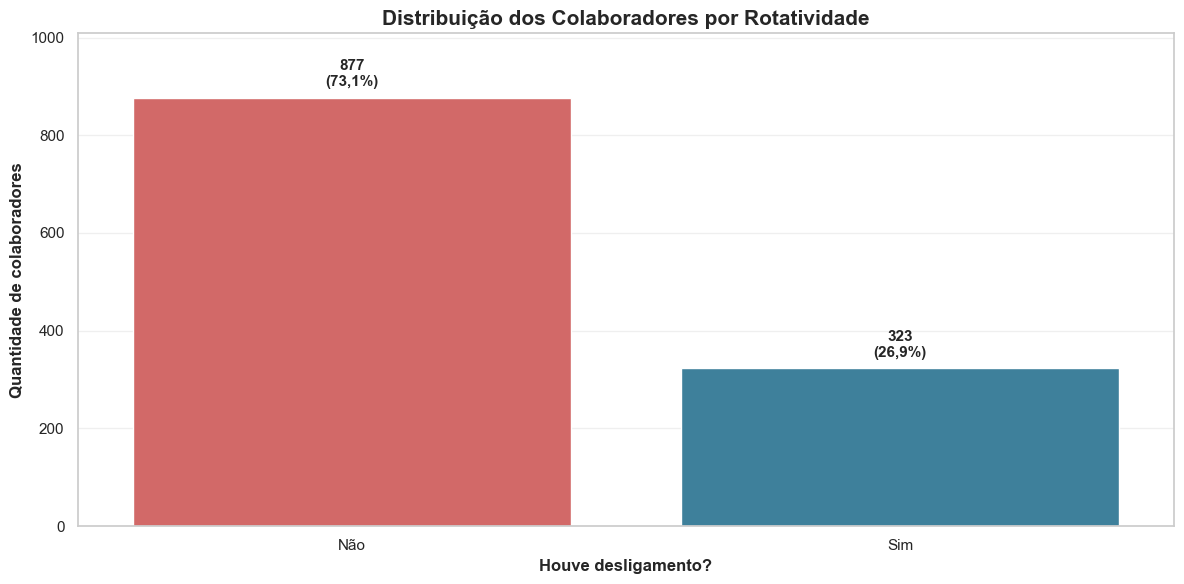

Gráfico salvo em: ..\imagens\distribuicao_rotatividade.png


In [81]:
# Define a pasta e o caminho onde o gráfico será salvo
pasta_imagens = Path("../imagens")
pasta_imagens.mkdir(parents=True, exist_ok=True)

caminho_grafico = (
    pasta_imagens / "distribuicao_rotatividade.png"
)

# Define a ordem das categorias e as cores utilizadas
ordem_rotatividade = ["Não", "Sim"]
cores_rotatividade = ["#2E86AB", "#E45756"]

# Cria o gráfico de distribuição dos colaboradores
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df,
    x="rotatividade",
    order=ordem_rotatividade,
    hue="rotatividade",
    palette=cores_rotatividade,
    legend=False
)

# Adiciona a quantidade e o percentual acima de cada barra
for barra in ax.patches:
    quantidade = int(barra.get_height())
    percentual = quantidade / len(df)

    percentual_formatado = (
        f"{percentual:.1%}".replace(".", ",")
    )

    ax.annotate(
        f"{quantidade}\n({percentual_formatado})",
        xy=(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height()
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Adiciona espaço acima das barras para melhorar a visualização dos rótulos
ax.set_ylim(
    0,
    max(total_ativos, total_desligados) * 1.15
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Distribuição dos Colaboradores por Rotatividade",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Houve desligamento?",
    fontweight="bold"
)
plt.ylabel(
    "Quantidade de colaboradores",
    fontweight="bold"
)

# Configura a grade e ajusta o layout
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico no notebook
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

# 3. Análise da Rotatividade por Área

A análise por área permite identificar quais setores apresentam maior proporção de desligamentos.

Para evitar interpretações equivocadas causadas por diferenças no tamanho das equipes, será calculada a taxa de rotatividade de cada área, considerando a relação entre desligados e total de colaboradores.

In [82]:
# Agrupa os colaboradores por área e calcula o total de pessoas e desligamentos
rotatividade_por_area = (
    df.groupby("area")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada área
rotatividade_por_area["taxa_rotatividade"] = (
    rotatividade_por_area["total_desligados"]
    / rotatividade_por_area["total_colaboradores"]
)

# Ordena as áreas da maior para a menor taxa de rotatividade
rotatividade_por_area = (
    rotatividade_por_area
    .sort_values(
        by="taxa_rotatividade",
        ascending=False
    )
    .reset_index(drop=True)
)

# Exibe a tabela com o percentual formatado
display(
    rotatividade_por_area.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,area,total_colaboradores,total_desligados,taxa_rotatividade
0,Atendimento,167,56,33.53%
1,Marketing,165,48,29.09%
2,Financeiro,166,45,27.11%
3,Operações,173,46,26.59%
4,Recursos Humanos,182,48,26.37%
5,Comercial,170,43,25.29%
6,Tecnologia,177,37,20.90%


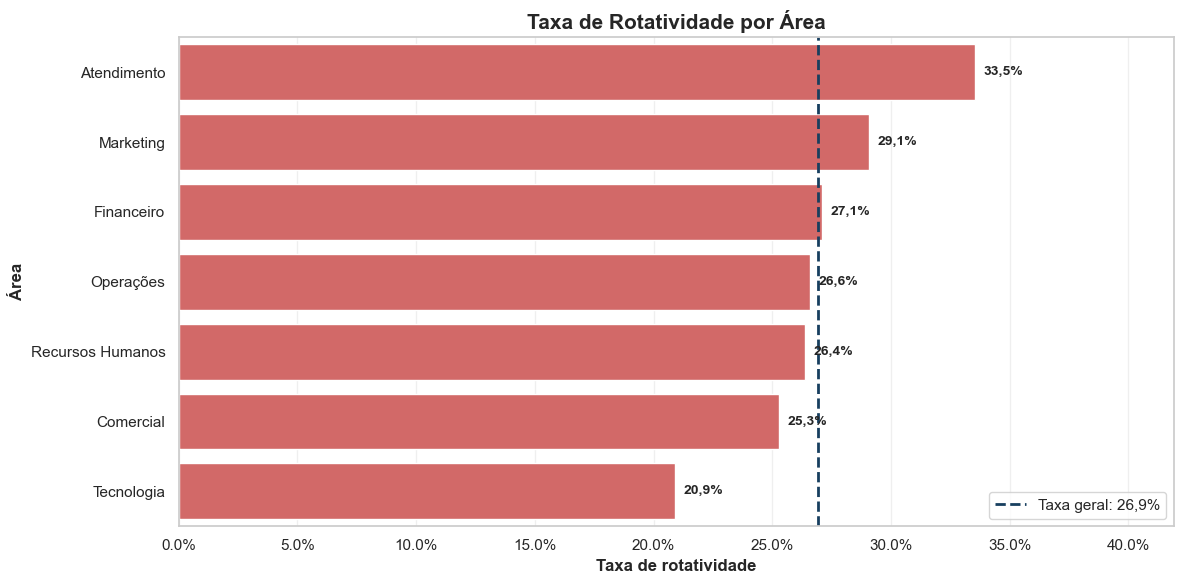

Gráfico salvo em: ..\imagens\rotatividade_por_area.png


In [83]:
# Importa o formatador utilizado para apresentar o eixo em percentual
from matplotlib.ticker import PercentFormatter

# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens / "rotatividade_por_area.png"
)

# Cria o gráfico horizontal com a taxa de rotatividade por área
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_por_area,
    y="area",
    x="taxa_rotatividade",
    color="#E45756"
)

# Adiciona o percentual ao final de cada barra
for barra in ax.patches:
    taxa = barra.get_width()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            taxa,
            barra.get_y() + barra.get_height() / 2
        ),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona uma linha de referência com a taxa geral de rotatividade
ax.axvline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Área",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Taxa de rotatividade",
    fontweight="bold"
)
plt.ylabel(
    "Área",
    fontweight="bold"
)

# Formata o eixo horizontal como percentual
ax.xaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_xlim(
    0,
    rotatividade_por_area["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="x",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 3.1 Conclusão Executiva — Rotatividade por Área

A área de Atendimento apresenta a maior taxa de rotatividade, com 33,5%, resultado 6,6 pontos percentuais acima da taxa geral de 26,9%. Esse resultado indica que a área deve ser priorizada nas análises de retenção.

Marketing ocupa a segunda posição, com 29,1%, enquanto o Financeiro apresenta 27,1%, praticamente alinhado ao indicador geral.

Tecnologia possui a menor taxa de rotatividade, com 20,9%, aproximadamente 6 pontos percentuais abaixo da média. A diferença entre Atendimento e Tecnologia é de 12,6 pontos percentuais, evidenciando comportamentos distintos entre as áreas.

Os resultados sugerem a necessidade de aprofundar a análise de Atendimento e Marketing, considerando fatores como horas extras, satisfação, remuneração e tempo de empresa. As diferenças observadas representam associações e não comprovam, isoladamente, relações de causa e efeito.

# 4. Relação entre Horas Extras e Rotatividade

Nesta etapa, será analisada a taxa de rotatividade entre colaboradores que realizam e que não realizam horas extras.

A comparação permite verificar se existe uma associação entre carga adicional de trabalho e desligamentos, sem estabelecer uma relação direta de causalidade.

In [84]:
# Agrupa os colaboradores por realização de horas extras e calcula os desligamentos
rotatividade_horas_extras = (
    df.groupby("horas_extras")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada grupo
rotatividade_horas_extras["taxa_rotatividade"] = (
    rotatividade_horas_extras["total_desligados"]
    / rotatividade_horas_extras["total_colaboradores"]
)

# Ordena os grupos para facilitar a comparação
rotatividade_horas_extras["horas_extras"] = pd.Categorical(
    rotatividade_horas_extras["horas_extras"],
    categories=["Não", "Sim"],
    ordered=True
)

rotatividade_horas_extras = (
    rotatividade_horas_extras
    .sort_values("horas_extras")
    .reset_index(drop=True)
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_horas_extras.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,horas_extras,total_colaboradores,total_desligados,taxa_rotatividade
0,Não,776,199,25.64%
1,Sim,424,124,29.25%


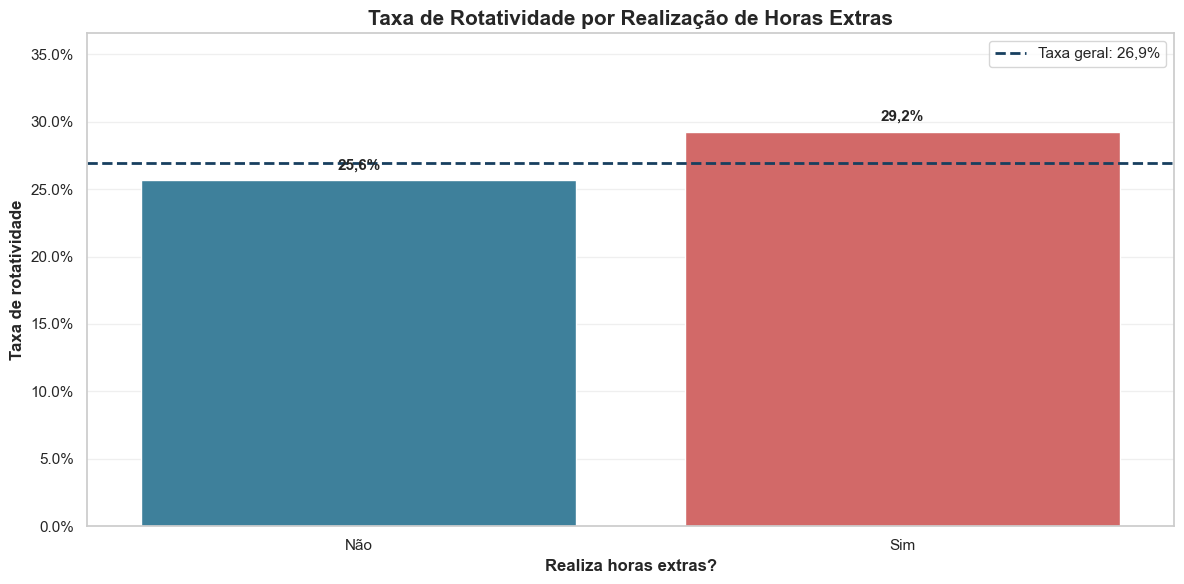

Gráfico salvo em: ..\imagens\rotatividade_por_horas_extras.png


In [85]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens / "rotatividade_por_horas_extras.png"
)

# Define as cores utilizadas para diferenciar os grupos
cores_horas_extras = ["#2E86AB", "#E45756"]

# Cria o gráfico com a taxa de rotatividade por realização de horas extras
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_horas_extras,
    x="horas_extras",
    y="taxa_rotatividade",
    hue="horas_extras",
    palette=cores_horas_extras,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral de rotatividade
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Realização de Horas Extras",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Realiza horas extras?",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_ylim(
    0,
    rotatividade_horas_extras["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 4.1 Conclusão Executiva — Horas Extras

Os colaboradores que realizam horas extras apresentam taxa de rotatividade de 29,2%, enquanto aqueles que não realizam possuem taxa de 25,6%.

A diferença é de 3,6 pontos percentuais. Em termos relativos, a rotatividade do grupo que realiza horas extras é aproximadamente 14% maior.

O grupo com horas extras também está 2,3 pontos percentuais acima da taxa geral de 26,9%. Já o grupo sem horas extras permanece 1,3 ponto percentual abaixo do indicador geral.

Os resultados indicam uma associação entre horas extras e maior rotatividade. Entretanto, a diferença é menor que a variação observada entre as áreas, sugerindo que a carga adicional de trabalho pode contribuir para os desligamentos, mas não deve ser analisada como fator isolado.

Recomenda-se acompanhar a frequência de horas extras por área e investigar possíveis relações com sobrecarga, satisfação, equilíbrio entre vida pessoal e trabalho e intenção de permanência.

# 5. Relação entre Satisfação no Trabalho e Rotatividade

A satisfação no trabalho pode estar associada à permanência dos colaboradores na organização.

Nesta etapa, será calculada a taxa de rotatividade para cada nível de satisfação, considerando uma escala de 1 a 5, em que 1 representa satisfação muito baixa e 5 representa satisfação muito alta.

In [86]:
# Agrupa os colaboradores por nível de satisfação e calcula os desligamentos
rotatividade_satisfacao = (
    df.groupby("satisfacao_trabalho")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada nível de satisfação
rotatividade_satisfacao["taxa_rotatividade"] = (
    rotatividade_satisfacao["total_desligados"]
    / rotatividade_satisfacao["total_colaboradores"]
)

# Ordena os resultados do menor para o maior nível de satisfação
rotatividade_satisfacao = (
    rotatividade_satisfacao
    .sort_values("satisfacao_trabalho")
    .reset_index(drop=True)
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_satisfacao.style.format({
        "satisfacao_trabalho": "{:.0f}",
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,satisfacao_trabalho,total_colaboradores,total_desligados,taxa_rotatividade
0,1,222,73,32.88%
1,2,231,79,34.20%
2,3,267,63,23.60%
3,4,244,57,23.36%
4,5,236,51,21.61%


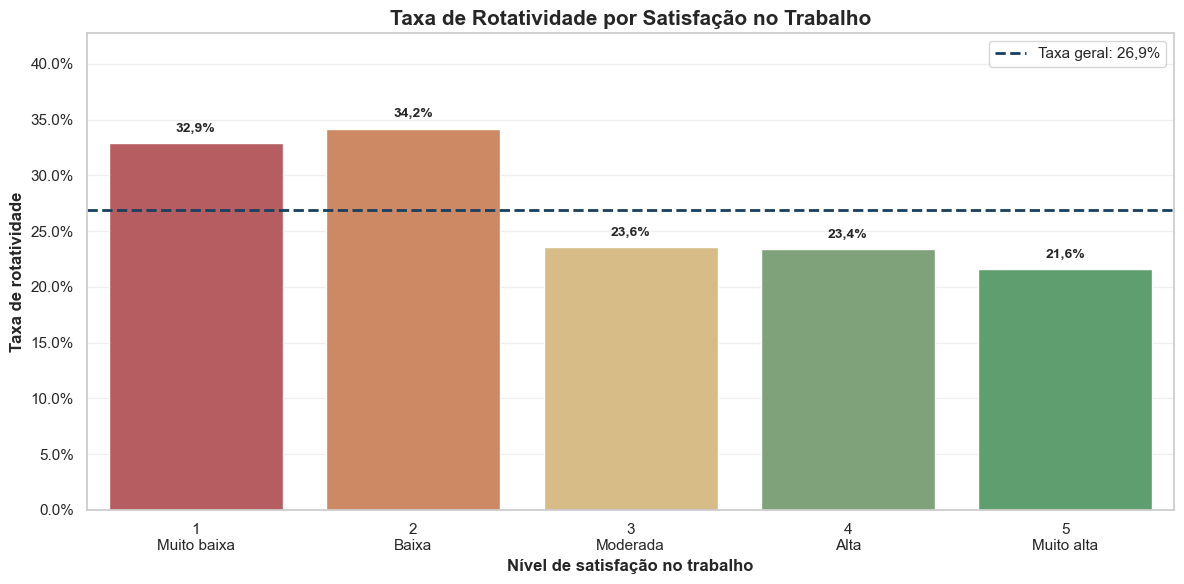

Gráfico salvo em: ..\imagens\rotatividade_por_satisfacao_trabalho.png


In [87]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_satisfacao_trabalho.png"
)

# Define uma escala de cores do vermelho ao verde para representar os níveis de satisfação
cores_satisfacao = [
    "#C44E52",
    "#DD8452",
    "#E5C07B",
    "#7AA974",
    "#55A868"
]

# Cria o gráfico com a taxa de rotatividade por nível de satisfação
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_satisfacao,
    x="satisfacao_trabalho",
    y="taxa_rotatividade",
    hue="satisfacao_trabalho",
    palette=cores_satisfacao,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral de rotatividade
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Satisfação no Trabalho",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Nível de satisfação no trabalho",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Substitui os valores da escala por descrições mais claras
plt.xticks(
    ticks=[0, 1, 2, 3, 4],
    labels=[
        "1\nMuito baixa",
        "2\nBaixa",
        "3\nModerada",
        "4\nAlta",
        "5\nMuito alta"
    ]
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_ylim(
    0,
    rotatividade_satisfacao["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 5.1 Conclusão Executiva — Satisfação no Trabalho

Os colaboradores com níveis baixos de satisfação apresentam as maiores taxas de rotatividade. O nível 2 registra a maior taxa, com 34,2%, seguido pelo nível 1, com 32,9%. Ambos permanecem significativamente acima da taxa geral de 26,9%.

A partir do nível 3, observa-se uma redução relevante nos desligamentos. Os colaboradores com satisfação moderada apresentam taxa de 23,6%, enquanto os níveis 4 e 5 registram 23,4% e 21,6%, respectivamente.

A diferença entre a maior taxa, observada no nível 2, e a menor taxa, registrada no nível 5, é de 12,6 pontos percentuais. Em termos relativos, a rotatividade do nível 2 é aproximadamente 58% maior que a do grupo com satisfação muito alta.

Embora não exista uma redução perfeitamente linear entre todos os níveis, os resultados revelam uma separação clara: colaboradores com satisfação baixa apresentam maior propensão ao desligamento do que aqueles com satisfação moderada ou alta.

Recomenda-se priorizar pesquisas de clima, acompanhamento da liderança, reconhecimento, oportunidades de desenvolvimento e análise da carga de trabalho entre colaboradores com avaliações de satisfação iguais ou inferiores a 2.

# 6. Rotatividade por Tempo de Empresa

Nesta etapa, os colaboradores serão agrupados de acordo com o tempo de permanência na organização.

A análise permite identificar períodos mais críticos da jornada do colaborador e apoiar ações de onboarding, desenvolvimento, reconhecimento e retenção.

In [88]:
# Define os limites e os nomes das faixas de tempo de empresa
limites_tempo_empresa = [
    -1,
    1,
    3,
    6,
    10,
    np.inf
]

nomes_faixas_tempo = [
    "Até 1 ano",
    "2 a 3 anos",
    "4 a 6 anos",
    "7 a 10 anos",
    "Acima de 10 anos"
]

# Classifica cada colaborador de acordo com o tempo de empresa
df["faixa_tempo_empresa"] = pd.cut(
    df["tempo_empresa_anos"],
    bins=limites_tempo_empresa,
    labels=nomes_faixas_tempo,
    ordered=True
)

# Confirma a quantidade de colaboradores em cada faixa
df["faixa_tempo_empresa"].value_counts(
    sort=False
)

faixa_tempo_empresa
Até 1 ano           229
2 a 3 anos          187
4 a 6 anos          249
7 a 10 anos         295
Acima de 10 anos    240
Name: count, dtype: int64

In [89]:
# Agrupa os colaboradores por faixa de tempo e calcula os desligamentos
rotatividade_tempo_empresa = (
    df.groupby(
        "faixa_tempo_empresa",
        observed=False
    )
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada faixa de tempo
rotatividade_tempo_empresa["taxa_rotatividade"] = (
    rotatividade_tempo_empresa["total_desligados"]
    / rotatividade_tempo_empresa["total_colaboradores"]
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_tempo_empresa.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,faixa_tempo_empresa,total_colaboradores,total_desligados,taxa_rotatividade
0,Até 1 ano,229,73,31.88%
1,2 a 3 anos,187,58,31.02%
2,4 a 6 anos,249,55,22.09%
3,7 a 10 anos,295,74,25.08%
4,Acima de 10 anos,240,63,26.25%


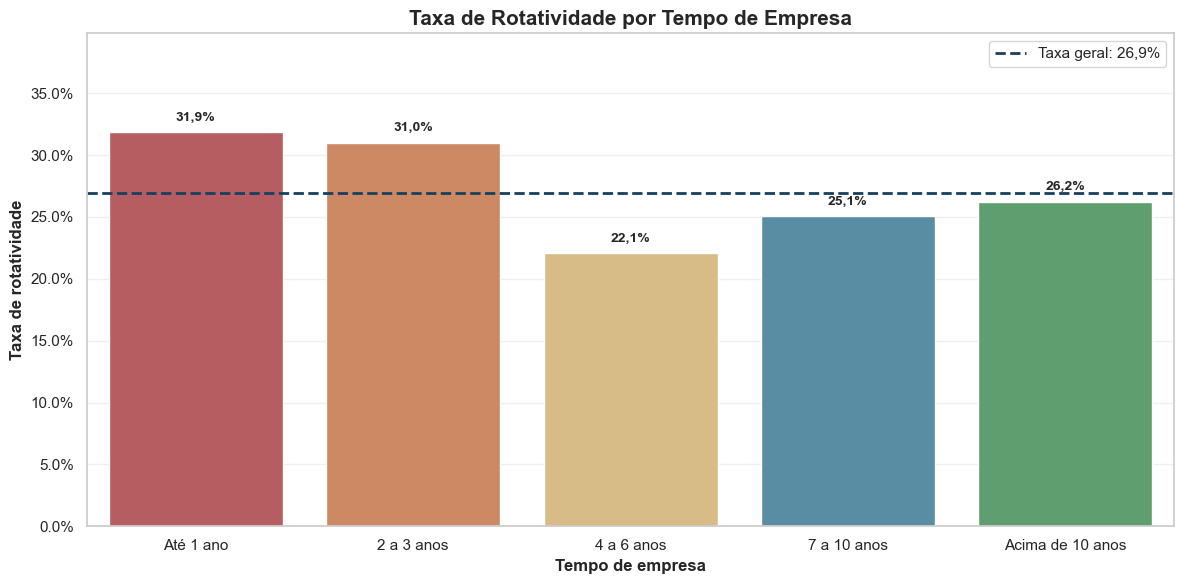

Gráfico salvo em: ..\imagens\rotatividade_por_tempo_empresa.png


In [90]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_tempo_empresa.png"
)

# Define as cores utilizadas nas faixas de tempo
cores_tempo_empresa = [
    "#C44E52",
    "#DD8452",
    "#E5C07B",
    "#4C92B0",
    "#55A868"
]

# Cria o gráfico com a taxa de rotatividade por tempo de empresa
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_tempo_empresa,
    x="faixa_tempo_empresa",
    y="taxa_rotatividade",
    hue="faixa_tempo_empresa",
    palette=cores_tempo_empresa,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral de rotatividade
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Tempo de Empresa",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Tempo de empresa",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_ylim(
    0,
    rotatividade_tempo_empresa["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 6.1 Conclusão Executiva — Tempo de Empresa

Os colaboradores com até 1 ano de empresa apresentam a maior taxa de rotatividade, com 31,9%. Entre 2 e 3 anos, o indicador permanece elevado, alcançando 31,0%. As duas faixas estão acima da taxa geral de 26,9%.

A menor rotatividade ocorre entre 4 e 6 anos, com 22,1%. A diferença entre esse grupo e os colaboradores com até 1 ano é de 9,8 pontos percentuais.

Entre 7 e 10 anos, a taxa aumenta para 25,1%, enquanto colaboradores com mais de 10 anos apresentam 26,2%. Apesar desse crescimento, os dois grupos permanecem abaixo da taxa geral.

Os resultados indicam que o período de maior risco de desligamento está concentrado nos três primeiros anos. A queda observada entre 4 e 6 anos sugere que colaboradores que ultrapassam a fase inicial tendem a alcançar maior estabilidade.

Recomenda-se fortalecer o onboarding, estabelecer metas de 30, 60 e 90 dias, realizar acompanhamentos periódicos com a liderança e estruturar conversas de carreira durante os primeiros três anos. Entrevistas de permanência nos primeiros 6, 12 e 24 meses também podem ajudar a identificar riscos antes do desligamento.

# 7. Relação entre Faixa Salarial e Rotatividade

Nesta etapa, os colaboradores serão classificados em quatro faixas salariais com quantidades semelhantes de registros.

O primeiro quartil representa os menores salários da base, enquanto o quarto quartil reúne os maiores salários. Essa divisão permite comparar a rotatividade entre diferentes níveis de remuneração.

In [91]:
# Define os nomes utilizados para representar os quartis salariais
nomes_faixas_salariais = [
    "1º quartil",
    "2º quartil",
    "3º quartil",
    "4º quartil"
]

# Divide os colaboradores em quatro faixas de acordo com a distribuição salarial
df["faixa_salarial"] = pd.qcut(
    df["salario_mensal"],
    q=4,
    labels=nomes_faixas_salariais
)

# Confirma a quantidade de colaboradores em cada faixa salarial
df["faixa_salarial"].value_counts(
    sort=False
)

faixa_salarial
1º quartil    300
2º quartil    301
3º quartil    308
4º quartil    291
Name: count, dtype: int64

In [92]:
# Agrupa os colaboradores por faixa salarial e calcula os principais indicadores
rotatividade_faixa_salarial = (
    df.groupby(
        "faixa_salarial",
        observed=False
    )
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        ),
        salario_minimo=(
            "salario_mensal",
            "min"
        ),
        salario_medio=(
            "salario_mensal",
            "mean"
        ),
        salario_maximo=(
            "salario_mensal",
            "max"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada faixa salarial
rotatividade_faixa_salarial["taxa_rotatividade"] = (
    rotatividade_faixa_salarial["total_desligados"]
    / rotatividade_faixa_salarial["total_colaboradores"]
)

# Exibe a tabela com os valores formatados
display(
    rotatividade_faixa_salarial.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "salario_minimo": "R$ {:,.2f}",
        "salario_medio": "R$ {:,.2f}",
        "salario_maximo": "R$ {:,.2f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,faixa_salarial,total_colaboradores,total_desligados,salario_minimo,salario_medio,salario_maximo,taxa_rotatividade
0,1º quartil,300,90,"R$ 3,750.00","R$ 6,257.50","R$ 7,350.00",30.00%
1,2º quartil,301,83,"R$ 7,400.00","R$ 8,205.15","R$ 9,000.00",27.57%
2,3º quartil,308,81,"R$ 9,050.00","R$ 9,888.31","R$ 10,700.00",26.30%
3,4º quartil,291,69,"R$ 10,750.00","R$ 12,065.64","R$ 14,800.00",23.71%


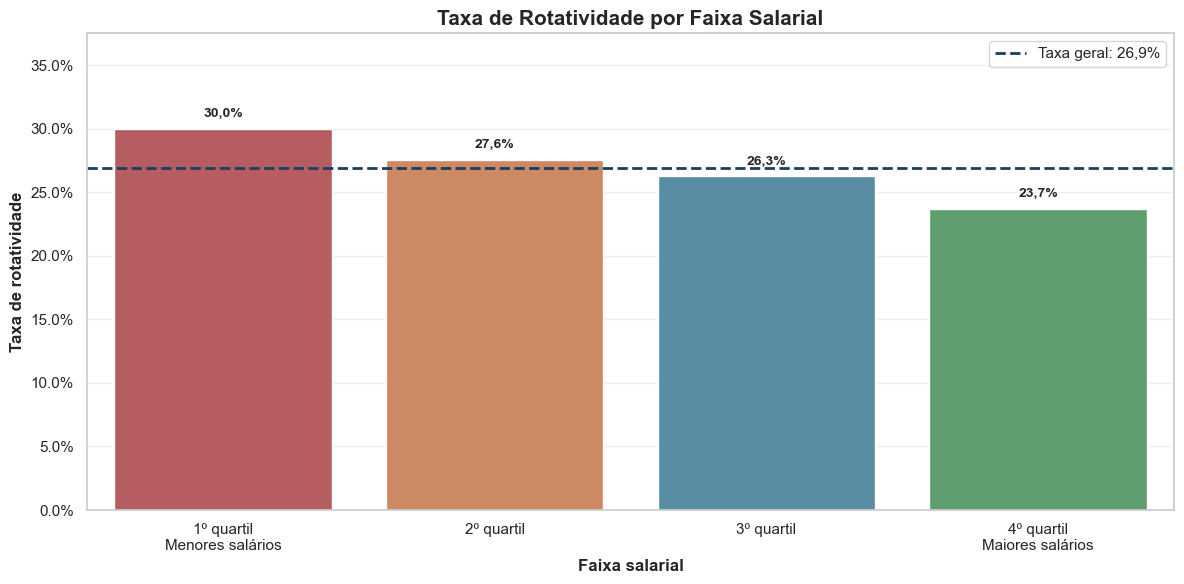

Gráfico salvo em: ..\imagens\rotatividade_por_faixa_salarial.png


In [93]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_faixa_salarial.png"
)

# Define as cores utilizadas para representar os quartis salariais
cores_faixas_salariais = [
    "#C44E52",
    "#DD8452",
    "#4C92B0",
    "#55A868"
]

# Cria o gráfico com a taxa de rotatividade por faixa salarial
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_faixa_salarial,
    x="faixa_salarial",
    y="taxa_rotatividade",
    hue="faixa_salarial",
    palette=cores_faixas_salariais,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral de rotatividade
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Faixa Salarial",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Faixa salarial",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Acrescenta uma descrição para facilitar a leitura dos quartis
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "1º quartil\nMenores salários",
        "2º quartil",
        "3º quartil",
        "4º quartil\nMaiores salários"
    ]
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_ylim(
    0,
    rotatividade_faixa_salarial["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 7.1 Conclusão Executiva — Faixa Salarial

Os colaboradores pertencentes ao primeiro quartil, que reúne os menores salários da base, apresentam a maior taxa de rotatividade, com 30,0%. O resultado está 3,1 pontos percentuais acima da taxa geral de 26,9%.

No segundo quartil, a taxa diminui para 27,6%. O terceiro quartil apresenta 26,3%, enquanto o grupo com os maiores salários registra a menor taxa, com 23,7%.

A diferença entre o primeiro e o quarto quartil é de 6,3 pontos percentuais. Em termos relativos, a rotatividade entre os menores salários é aproximadamente 27% maior que entre os maiores salários.

Os resultados indicam uma associação inversa entre remuneração e desligamento: conforme o nível salarial aumenta, a taxa de rotatividade diminui. Entretanto, o salário também pode estar relacionado ao cargo, senioridade, área e tempo de empresa, não devendo ser interpretado como causa isolada.

Recomenda-se revisar a competitividade salarial das faixas iniciais, analisar a equidade interna entre cargos semelhantes e combinar remuneração com oportunidades de desenvolvimento e progressão profissional.

# 8. Relação entre Promoção e Rotatividade

Nesta etapa, será comparada a taxa de rotatividade entre colaboradores que receberam e que não receberam promoção nos últimos cinco anos.

A análise permite verificar se oportunidades de crescimento profissional estão associadas à permanência dos colaboradores.

In [94]:
# Agrupa os colaboradores pelo histórico de promoção e calcula os desligamentos
rotatividade_promocao = (
    df.groupby("recebeu_promocao_5_anos")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada grupo
rotatividade_promocao["taxa_rotatividade"] = (
    rotatividade_promocao["total_desligados"]
    / rotatividade_promocao["total_colaboradores"]
)

# Define uma ordem lógica para apresentação dos resultados
rotatividade_promocao["recebeu_promocao_5_anos"] = pd.Categorical(
    rotatividade_promocao["recebeu_promocao_5_anos"],
    categories=["Não", "Sim"],
    ordered=True
)

rotatividade_promocao = (
    rotatividade_promocao
    .sort_values("recebeu_promocao_5_anos")
    .reset_index(drop=True)
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_promocao.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,recebeu_promocao_5_anos,total_colaboradores,total_desligados,taxa_rotatividade
0,Não,901,257,28.52%
1,Sim,299,66,22.07%


# 9. Equilíbrio entre Vida Pessoal e Trabalho

Nesta etapa, será analisada a taxa de rotatividade para cada nível de equilíbrio entre vida pessoal e trabalho.

A variável utiliza uma escala de 1 a 5, em que valores menores representam uma percepção mais negativa de equilíbrio.

In [95]:
# Agrupa os colaboradores por nível de equilíbrio e calcula os desligamentos
rotatividade_equilibrio = (
    df.groupby("equilibrio_vida_trabalho")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada nível de equilíbrio
rotatividade_equilibrio["taxa_rotatividade"] = (
    rotatividade_equilibrio["total_desligados"]
    / rotatividade_equilibrio["total_colaboradores"]
)

# Ordena os resultados de acordo com o nível de equilíbrio
rotatividade_equilibrio = (
    rotatividade_equilibrio
    .sort_values("equilibrio_vida_trabalho")
    .reset_index(drop=True)
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_equilibrio.style.format({
        "equilibrio_vida_trabalho": "{:.0f}",
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,equilibrio_vida_trabalho,total_colaboradores,total_desligados,taxa_rotatividade
0,1,230,77,33.48%
1,2,255,76,29.80%
2,3,232,59,25.43%
3,4,236,51,21.61%
4,5,247,60,24.29%


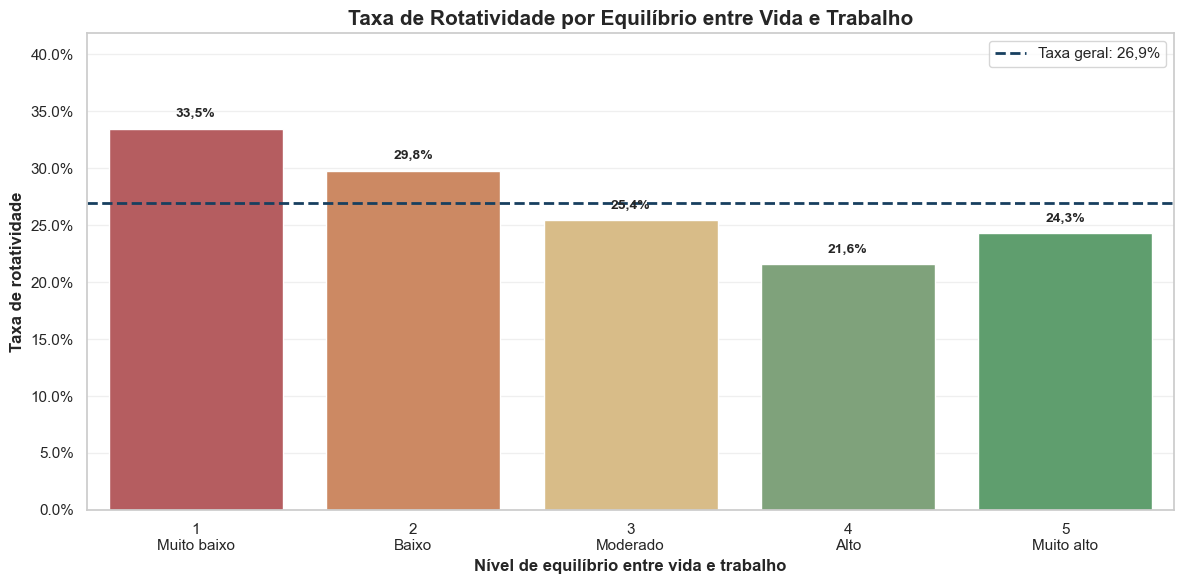

Gráfico salvo em: ..\imagens\rotatividade_por_equilibrio_vida_trabalho.png


In [96]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_equilibrio_vida_trabalho.png"
)

# Define uma escala de cores do vermelho ao verde
cores_equilibrio = [
    "#C44E52",
    "#DD8452",
    "#E5C07B",
    "#7AA974",
    "#55A868"
]

# Cria o gráfico com a taxa de rotatividade por nível de equilíbrio
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_equilibrio,
    x="equilibrio_vida_trabalho",
    y="taxa_rotatividade",
    hue="equilibrio_vida_trabalho",
    palette=cores_equilibrio,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Equilíbrio entre Vida e Trabalho",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Nível de equilíbrio entre vida e trabalho",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Substitui os valores da escala por descrições
plt.xticks(
    ticks=[0, 1, 2, 3, 4],
    labels=[
        "1\nMuito baixo",
        "2\nBaixo",
        "3\nModerado",
        "4\nAlto",
        "5\nMuito alto"
    ]
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura o layout
ax.set_ylim(
    0,
    rotatividade_equilibrio["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 9.1 Conclusão Executiva — Equilíbrio entre Vida e Trabalho

Os colaboradores que avaliam o equilíbrio entre vida pessoal e trabalho como muito baixo apresentam a maior taxa de rotatividade, com 33,5%. O resultado está 6,6 pontos percentuais acima da taxa geral de 26,9%.

O nível 2 também permanece acima da média, com taxa de 29,8%. A partir do nível 3, os resultados ficam abaixo da taxa geral: 25,4% no nível moderado, 21,6% no nível alto e 24,3% no nível muito alto.

A diferença entre a maior taxa, registrada no nível 1, e a menor, observada no nível 4, é de 11,9 pontos percentuais. Em termos relativos, a rotatividade do grupo com equilíbrio muito baixo é aproximadamente 55% maior.

Apesar do pequeno aumento entre os níveis 4 e 5, existe uma separação clara entre os colaboradores com equilíbrio baixo e aqueles com percepção moderada ou alta.

Recomenda-se acompanhar carga de trabalho, horas extras, flexibilidade, qualidade da liderança e iniciativas de bem-estar. Pesquisas periódicas também podem ajudar a identificar sinais de sobrecarga antes que resultem em desligamentos.

# 10. Acúmulo de Fatores Associados à Rotatividade

Nesta etapa, serão combinados cinco fatores que apresentaram associação com maior rotatividade:

- satisfação no trabalho baixa;
- equilíbrio entre vida e trabalho baixo;
- realização de horas extras;
- até três anos de empresa;
- pertencimento à menor faixa salarial.

O indicador possui finalidade exclusivamente exploratória. Ele não deve ser utilizado isoladamente para avaliar colaboradores ou tomar decisões individuais.

In [97]:
# Cria indicadores binários para cada fator associado à maior rotatividade
df["fator_satisfacao_baixa"] = (
    df["satisfacao_trabalho"]
    .le(2)
    .astype(int)
)

df["fator_equilibrio_baixo"] = (
    df["equilibrio_vida_trabalho"]
    .le(2)
    .astype(int)
)

df["fator_horas_extras"] = (
    df["horas_extras"]
    .eq("Sim")
    .astype(int)
)

df["fator_pouco_tempo_empresa"] = (
    df["tempo_empresa_anos"]
    .le(3)
    .astype(int)
)

df["fator_menor_faixa_salarial"] = (
    df["faixa_salarial"]
    .eq("1º quartil")
    .astype(int)
)

In [98]:
# Define as colunas utilizadas no cálculo do indicador exploratório
colunas_fatores = [
    "fator_satisfacao_baixa",
    "fator_equilibrio_baixo",
    "fator_horas_extras",
    "fator_pouco_tempo_empresa",
    "fator_menor_faixa_salarial"
]

# Calcula quantos fatores estão presentes em cada registro
df["quantidade_fatores"] = (
    df[colunas_fatores]
    .sum(axis=1)
)

# Exibe a distribuição da quantidade de fatores encontrados
df["quantidade_fatores"].value_counts(
    sort=False
)

quantidade_fatores
1    374
2    398
0    150
3    212
4     58
5      8
Name: count, dtype: int64

In [99]:
# Agrupa a quantidade de fatores em categorias de fácil interpretação
df["grupo_fatores"] = pd.cut(
    df["quantidade_fatores"],
    bins=[
        -1,
        0,
        1,
        2,
        5
    ],
    labels=[
        "Nenhum fator",
        "1 fator",
        "2 fatores",
        "3 ou mais fatores"
    ],
    ordered=True
)

# Confirma a quantidade de colaboradores em cada grupo
df["grupo_fatores"].value_counts(
    sort=False
)

grupo_fatores
Nenhum fator         150
1 fator              374
2 fatores            398
3 ou mais fatores    278
Name: count, dtype: int64

In [100]:
# Agrupa os colaboradores pela quantidade acumulada de fatores
rotatividade_fatores = (
    df.groupby(
        "grupo_fatores",
        observed=False
    )
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
       
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada grupo
rotatividade_fatores["taxa_rotatividade"] = (
    rotatividade_fatores["total_desligados"]
    / rotatividade_fatores["total_colaboradores"]
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_fatores.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,grupo_fatores,total_colaboradores,total_desligados,taxa_rotatividade
0,Nenhum fator,150,22,14.67%
1,1 fator,374,87,23.26%
2,2 fatores,398,113,28.39%
3,3 ou mais fatores,278,101,36.33%


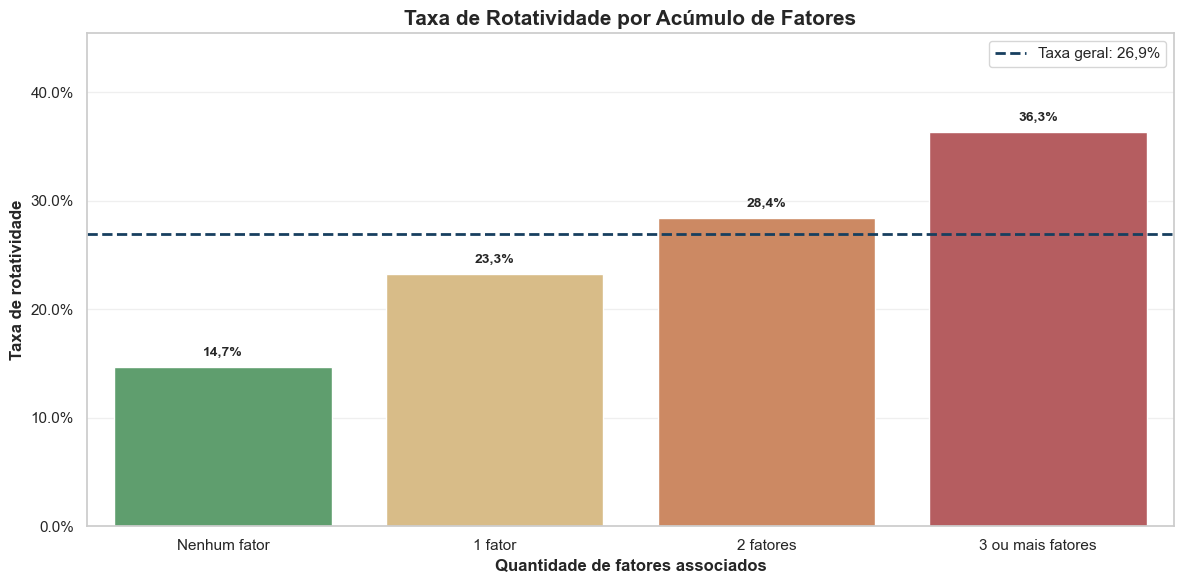

Gráfico salvo em: ..\imagens\rotatividade_por_acumulo_de_fatores.png


In [101]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_acumulo_de_fatores.png"
)

# Define uma escala de cores conforme o acúmulo de fatores
cores_fatores = [
    "#55A868",
    "#E5C07B",
    "#DD8452",
    "#C44E52"
]

# Cria o gráfico com a taxa de rotatividade por acúmulo de fatores
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_fatores,
    x="grupo_fatores",
    y="taxa_rotatividade",
    hue="grupo_fatores",
    palette=cores_fatores,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Acúmulo de Fatores",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Quantidade de fatores associados",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura o layout
ax.set_ylim(
    0,
    rotatividade_fatores["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 10.1 Conclusão Executiva — Acúmulo de Fatores

A taxa de rotatividade aumenta progressivamente conforme os fatores associados se acumulam.

Colaboradores sem nenhum dos fatores analisados apresentam taxa de rotatividade de 14,7%, resultado 12,2 pontos percentuais abaixo da taxa geral de 26,9%.

Com um fator, a taxa aumenta para 23,3%. Entre colaboradores com dois fatores, o indicador alcança 28,4%, ultrapassando a média geral.

O grupo com três ou mais fatores apresenta a maior taxa, com 36,3%. Esse resultado está 9,4 pontos percentuais acima da taxa geral e 21,6 pontos percentuais acima do grupo sem fatores.

Em termos relativos, a rotatividade entre colaboradores com três ou mais fatores é aproximadamente 2,5 vezes maior que entre aqueles sem nenhum fator.

Os resultados indicam que a combinação de satisfação baixa, desequilíbrio entre vida e trabalho, horas extras, pouco tempo de empresa e menor faixa salarial está associada a um aumento relevante dos desligamentos.

O indicador possui caráter exploratório e não deve ser utilizado para classificar ou tomar decisões sobre colaboradores individualmente. Sua aplicação recomendada é apoiar análises agregadas, priorização de políticas de retenção e monitoramento de grupos organizacionais.

# 11. Conclusão Executiva Final

## Visão Geral

A análise foi realizada sobre uma base bruta de 1.212 registros de colaboradores. Durante o processo de tratamento, foram identificadas e removidas 12 duplicidades, além do tratamento de 43 valores ausentes. A base final utilizada nas análises contém 1.200 registros únicos.

Foram identificados 323 desligamentos e 877 colaboradores ativos, resultando em uma taxa geral de rotatividade de 26,92%.

## Principais Insights

### Área organizacional

Atendimento apresentou a maior taxa de rotatividade, com 33,5%, enquanto Tecnologia registrou a menor, com 20,9%. A diferença de 12,6 pontos percentuais demonstra comportamentos distintos entre as áreas.

### Horas extras

Colaboradores que realizam horas extras apresentaram taxa de 29,2%, contra 25,6% entre aqueles que não realizam. A diferença indica uma possível associação entre carga adicional de trabalho e desligamento.

### Satisfação no trabalho

Os níveis baixos de satisfação apresentaram as maiores taxas de rotatividade, alcançando 34,2%. Entre colaboradores com satisfação muito alta, a taxa foi de 21,6%.

### Tempo de empresa

O período mais crítico está concentrado nos três primeiros anos. Colaboradores com até um ano apresentaram taxa de 31,9%, e aqueles entre dois e três anos registraram 31,0%.

### Faixa salarial

A rotatividade diminuiu conforme a faixa salarial aumentou. O primeiro quartil apresentou taxa de 30,0%, enquanto o grupo com os maiores salários registrou 23,7%.

### Promoção

Colaboradores sem promoção nos últimos cinco anos apresentaram taxa de 28,52%. Entre os promovidos, o indicador foi de 22,07%, diferença de 6,45 pontos percentuais.

### Equilíbrio entre vida e trabalho

O nível mais baixo de equilíbrio apresentou taxa de rotatividade de 33,5%. Nos níveis moderados e altos, os indicadores permaneceram abaixo da taxa geral.

### Acúmulo de fatores

Colaboradores sem os fatores analisados apresentaram taxa de rotatividade de 14,7%. Entre aqueles com três ou mais fatores, o indicador alcançou 36,3%, aproximadamente 2,5 vezes maior.

## Recomendações de Negócio

1. Fortalecer o onboarding e os acompanhamentos durante os três primeiros anos, com metas de 30, 60 e 90 dias e conversas de permanência aos 6, 12 e 24 meses.

2. Priorizar a área de Atendimento nas iniciativas de retenção, aprofundando a análise de liderança, carga de trabalho, remuneração e clima.

3. Monitorar horas extras e equilíbrio entre vida e trabalho, especialmente em equipes com taxas acima da média.

4. Estruturar planos de carreira, critérios transparentes de promoção e oportunidades de mobilidade interna.

5. Revisar a competitividade e a equidade salarial das faixas iniciais.

6. Criar um painel de acompanhamento com indicadores por área, tempo de empresa, satisfação, promoção e carga de trabalho.

7. Utilizar o acúmulo de fatores somente em análises agregadas, respeitando privacidade, ética e não discriminação.

## Limitações da Análise

A base utilizada é sintética e foi desenvolvida para fins educacionais e de portfólio. Os resultados representam associações presentes nos dados e não comprovam relações de causa e efeito.

O indicador de acúmulo de fatores possui caráter exploratório e não deve ser utilizado para tomar decisões individuais sobre colaboradores.

## Valor para o Negócio

O projeto demonstra como dados de pessoas podem ser transformados em informações acionáveis para apoiar estratégias de retenção, planejamento de pessoas e melhoria da experiência dos colaboradores.

A análise permite direcionar ações para grupos e momentos organizacionais mais críticos, tornando as decisões de People Analytics mais objetivas, preventivas e orientadas por dados.

# 12. Decisões Orientadas pelos Dados

Com base nos resultados encontrados, a organização pode tomar as seguintes decisões:

| Evidência encontrada | Decisão recomendada | Ação prática | Indicador de acompanhamento |
|---|---|---|---|
| Atendimento possui rotatividade de 33,5% | Priorizar Atendimento no plano de retenção | Investigar liderança, escala, volume de trabalho, remuneração e clima da área | Rotatividade mensal do Atendimento |
| Rotatividade supera 31% nos primeiros três anos | Reestruturar a jornada inicial do colaborador | Fortalecer onboarding, metas de 30, 60 e 90 dias e conversas de permanência | Rotatividade por tempo de empresa |
| Horas extras elevam a taxa para 29,2% | Revisar capacidade e distribuição do trabalho | Monitorar excesso de jornada, contratar ou redistribuir atividades quando necessário | Horas extras por área e taxa de desligamento |
| Satisfação baixa apresenta rotatividade acima de 32% | Criar ações direcionadas de clima e liderança | Aplicar pesquisas rápidas, desenvolver gestores e acompanhar planos de ação | Satisfação média e rotatividade |
| Equilíbrio muito baixo apresenta taxa de 33,5% | Ampliar políticas de equilíbrio e bem-estar | Avaliar flexibilidade, escalas, carga de trabalho e desconexão fora do expediente | Índice de equilíbrio e absenteísmo |
| Menores salários apresentam taxa de 30,0% | Revisar a competitividade das faixas iniciais | Comparar salários com o mercado e analisar equidade entre cargos semelhantes | Rotatividade por faixa salarial |
| Não promovidos apresentam taxa de 28,52% | Fortalecer carreira e mobilidade interna | Definir critérios transparentes, trilhas de carreira e divulgação de vagas internas | Promoções, mobilidade e rotatividade |
| Três ou mais fatores elevam a taxa para 36,3% | Priorizar grupos organizacionais com fatores acumulados | Direcionar ações agregadas para áreas e equipes com maior concentração de fatores | Taxa por quantidade de fatores |

## Priorização das Decisões

### Curto prazo

1. Investigar imediatamente a área de Atendimento.
2. Mapear equipes com excesso de horas extras.
3. Realizar conversas de permanência com colaboradores nos primeiros três anos.
4. Aplicar uma pesquisa de satisfação e equilíbrio entre vida e trabalho.

### Médio prazo

1. Revisar o processo de onboarding.
2. Estruturar planos de carreira e critérios de promoção.
3. Avaliar competitividade e equidade salarial.
4. Capacitar gestores das áreas com maior rotatividade.

### Acompanhamento contínuo

1. Criar um dashboard mensal de People Analytics.
2. Definir metas de redução da rotatividade por área.
3. Comparar os indicadores antes e depois de cada iniciativa.
4. Monitorar satisfação, horas extras, promoções e desligamentos.
5. Ajustar as ações de acordo com os resultados observados.

## Critério para Tomada de Decisão

As decisões não devem ser baseadas em apenas um indicador. Antes de implementar mudanças amplas, a organização deve combinar os resultados quantitativos com pesquisas de clima, entrevistas de desligamento, conversas com gestores e análise dos custos envolvidos.

O indicador de fatores acumulados deve ser utilizado exclusivamente para identificar tendências em grupos e equipes, nunca para classificar, punir ou tomar decisões individuais sobre colaboradores.

# 13. Finalização Técnica e Exportação dos Resultados

Nesta etapa, será exportada uma base analítica enriquecida com as variáveis criadas durante a análise.

Também será gerado um arquivo Excel com os KPIs e as tabelas de resumo, facilitando a construção do dashboard no Power BI e a documentação do projeto no GitHub.

In [103]:
# Organiza os principais KPIs em uma tabela numérica para exportação
kpis_exportacao = pd.DataFrame({
    "indicador": [
        "Total de colaboradores",
        "Colaboradores ativos",
        "Colaboradores desligados",
        "Taxa de rotatividade",
        "Idade média",
        "Tempo médio de empresa",
        "Salário médio"
    ],
    "valor": [
        total_colaboradores,
        total_ativos,
        total_desligados,
        taxa_rotatividade,
        idade_media,
        tempo_medio_empresa,
        salario_medio
    ],
    "unidade": [
        "colaboradores",
        "colaboradores",
        "colaboradores",
        "percentual",
        "anos",
        "anos",
        "reais"
    ]
})

# Exibe os KPIs que serão utilizados nos arquivos finais
kpis_exportacao

,indicador,valor,unidade
0,Total de colaboradores,1200.000000,colaboradores
1,Colaboradores ativos,877.000000,colaboradores
2,Colaboradores desligados,323.000000,colaboradores
3,Taxa de rotatividade,0.269167,percentual
4,Idade média,41.078333,anos
5,Tempo médio de empresa,6.033333,anos
6,Salário médio,9086.416667,reais


In [104]:
# Define e cria os diretórios utilizados nas exportações finais
pasta_dados = Path("../data")
pasta_powerbi = Path("../powerBi")

pasta_dados.mkdir(
    parents=True,
    exist_ok=True
)

pasta_powerbi.mkdir(
    parents=True,
    exist_ok=True
)

In [105]:
# Define o caminho do arquivo com os principais indicadores do projeto
caminho_kpis = (
    pasta_dados
    / "People_Analytics_Resumo_KPIs.csv"
)

# Exporta os KPIs em formato CSV
kpis_exportacao.to_csv(
    caminho_kpis,
    index=False,
    encoding="utf-8-sig"
)

In [106]:
# Define o caminho do arquivo Excel com as tabelas executivas
caminho_resumo_excel = (
    pasta_powerbi
    / "People_Analytics_Resumo_Executivo.xlsx"
)

# Exporta os KPIs e as tabelas analíticas para diferentes planilhas
with pd.ExcelWriter(
    caminho_resumo_excel,
    engine="openpyxl"
) as writer:

    kpis_exportacao.to_excel(
        writer,
        sheet_name="KPIs",
        index=False
    )

    rotatividade_por_area.to_excel(
        writer,
        sheet_name="Por Área",
        index=False
    )

    rotatividade_horas_extras.to_excel(
        writer,
        sheet_name="Horas Extras",
        index=False
    )

    rotatividade_satisfacao.to_excel(
        writer,
        sheet_name="Satisfação",
        index=False
    )

    rotatividade_tempo_empresa.to_excel(
        writer,
        sheet_name="Tempo de Empresa",
        index=False
    )

    rotatividade_faixa_salarial.to_excel(
        writer,
        sheet_name="Faixa Salarial",
        index=False
    )

    rotatividade_promocao.to_excel(
        writer,
        sheet_name="Promoção",
        index=False
    )

    rotatividade_equilibrio.to_excel(
        writer,
        sheet_name="Equilíbrio",
        index=False
    )

    rotatividade_fatores.to_excel(
        writer,
        sheet_name="Fatores Acumulados",
        index=False
    )

In [109]:
# Define novamente as pastas utilizadas na exportação
pasta_dados = Path("../data")
pasta_powerbi = Path("../powerBi")

# Garante que os diretórios estejam disponíveis
pasta_dados.mkdir(
    parents=True,
    exist_ok=True
)

pasta_powerbi.mkdir(
    parents=True,
    exist_ok=True
)

# Define os caminhos completos dos três arquivos finais
caminho_base_analitica = (
    pasta_dados
    / "People_Analytics_Base_Analitica.csv"
)

caminho_kpis = (
    pasta_dados
    / "People_Analytics_Resumo_KPIs.csv"
)

caminho_resumo_excel = (
    pasta_powerbi
    / "People_Analytics_Resumo_Executivo.xlsx"
)

In [110]:
# Confirma se todos os arquivos finais foram criados corretamente
arquivos_exportados = {
    "Base analítica": caminho_base_analitica,
    "Resumo de KPIs": caminho_kpis,
    "Resumo executivo": caminho_resumo_excel
}

# Apresenta o resultado da validação de cada arquivo
for nome, caminho in arquivos_exportados.items():
    print(
        f"{nome}: "
        f"{'Criado com sucesso' if caminho.exists() else 'Não encontrado'}"
    )

Base analítica: Não encontrado
Resumo de KPIs: Criado com sucesso
Resumo executivo: Criado com sucesso
